# 02. Preprocessing & Exploratory Data Analysis (EDA)
### Energy Demand Forecasting Pipeline

This notebook cleans the raw time series, resamples from hourly to daily/weekly frequency, executes a strict chronological 70/30 train/test split, and explores dominant seasonal patterns.

**Key Operations:**
- Handle isolated missing values via time-weighted linear interpolation
- Aggregate hourly load to daily mean load ($D$) and weekly mean load ($W-MON$)
- Enforce strict 70/30 chronological train/test split (no lookahead bias)
- Time-series decomposition, day-of-week load boxplots, and month-of-year seasonality

## 1. Setup & Ingestion

In [1]:
import os
import sys
import json
import hashlib
import logging
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

try:
    from IPython.display import display
except ImportError:
    display = print

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("energy_forecasting")

# Robust directory discovery
for base in [Path("."), Path(".."), Path("../..")]:
    candidate = base / "ml" / "data"
    if candidate.exists():
        PROJECT_ROOT = base.resolve()
        break
else:
    PROJECT_ROOT = Path(".").resolve()

ML_DIR = PROJECT_ROOT / "ml"
DATA_DIR = ML_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
ARTIFACTS_DIR = ML_DIR / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
FORECASTS_DIR = ARTIFACTS_DIR / "forecasts"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for d in [PROCESSED_DIR, REPORTS_DIR, MODELS_DIR, FORECASTS_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Locate raw 60min singleindex dataset
RAW_DATA_PATH = None
for candidate in [
    DATA_DIR / "opsd-time_series-2020-10-06" / "opsd-time_series-2020-10-06" / "time_series_60min_singleindex.csv",
    DATA_DIR / "time_series_60min_singleindex.csv",
    Path("ml/data/opsd-time_series-2020-10-06/opsd-time_series-2020-10-06/time_series_60min_singleindex.csv"),
    Path("data/opsd-time_series-2020-10-06/opsd-time_series-2020-10-06/time_series_60min_singleindex.csv"),
]:
    if candidate.exists():
        RAW_DATA_PATH = candidate.resolve()
        break

TIMESTAMP_COL = "utc_timestamp"
TARGET_COL_RAW = "DE_load_actual_entsoe_transparency"
TARGET_UNIT = "MW"
DS_COL = "ds"
Y_COL = "y"
TRAIN_RATIO = 0.70

print(f"Project root  : {PROJECT_ROOT}")
print(f"Raw data path : {RAW_DATA_PATH}")

print("Loading raw OPSD dataset...")
df_raw = pd.read_csv(
    RAW_DATA_PATH,
    usecols=[TIMESTAMP_COL, TARGET_COL_RAW],
    dtype={TARGET_COL_RAW: "float64"},
    low_memory=False
)
print(f"Loaded {len(df_raw):,} raw records.")

Project root  : C:\Users\Soham\OneDrive\Desktop\Energy Demand Forecasting
Raw data path : C:\Users\Soham\OneDrive\Desktop\Energy Demand Forecasting\ml\data\opsd-time_series-2020-10-06\opsd-time_series-2020-10-06\time_series_60min_singleindex.csv
Loading raw OPSD dataset...
Loaded 50,401 raw records.


## 2. Data Cleaning & Temporal Resampling

In [5]:
def clean_and_resample(df_raw: pd.DataFrame):
    """Clean raw 60-min series, interpolate missing values, and aggregate to daily and weekly."""
    df = df_raw.copy()
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], utc=True)
    df = df.drop_duplicates(subset=[TIMESTAMP_COL]).sort_values(TIMESTAMP_COL)
    df = df.set_index(TIMESTAMP_COL)
    
    # Linear interpolation for isolated nulls in target
    df[TARGET_COL_RAW] = df[TARGET_COL_RAW].interpolate(method="time").bfill().ffill()
    
    # Resample to Daily (mean MW load)
    daily_df = df[[TARGET_COL_RAW]].resample("D").mean()
    daily_df = daily_df.reset_index().rename(columns={TIMESTAMP_COL: DS_COL, TARGET_COL_RAW: Y_COL})
    daily_df[DS_COL] = pd.to_datetime(daily_df[DS_COL]).dt.tz_localize(None)
    
    # Resample to Weekly (mean MW load, week starting Monday)
    weekly_df = df[[TARGET_COL_RAW]].resample("W-MON").mean()
    weekly_df = weekly_df.reset_index().rename(columns={TIMESTAMP_COL: DS_COL, TARGET_COL_RAW: Y_COL})
    weekly_df[DS_COL] = pd.to_datetime(weekly_df[DS_COL]).dt.tz_localize(None)
    
    return daily_df, weekly_df

df_daily, df_weekly = clean_and_resample(df_raw)

# Save processed datasets
df_daily.to_csv(PROCESSED_DIR / "daily_full.csv", index=False)
df_weekly.to_csv(PROCESSED_DIR / "weekly_full.csv", index=False)

print(f"Daily resampled series : {len(df_daily):,} days ({df_daily['ds'].min().date()} to {df_daily['ds'].max().date()})")
print(f"Weekly resampled series: {len(df_weekly):,} weeks ({df_weekly['ds'].min().date()} to {df_weekly['ds'].max().date()})")
df_daily.head()

Daily resampled series : 2,101 days (2014-12-31 to 2020-09-30)
Weekly resampled series: 301 weeks (2015-01-05 to 2020-10-05)


,ds,y
0,2014-12-31,41151.000000
1,2015-01-01,45346.541667
2,2015-01-02,51941.166667
3,2015-01-03,46564.750000
4,2015-01-04,45082.500000


## 3. Chronological 70/30 Train/Test Split

In [6]:
def chronological_split(df: pd.DataFrame, train_ratio: float = 0.70):
    """Perform a strict chronological train/test split with zero leakage."""
    n_total = len(df)
    n_train = int(np.floor(n_total * train_ratio))
    
    train_df = df.iloc[:n_train].copy().reset_index(drop=True)
    test_df = df.iloc[n_train:].copy().reset_index(drop=True)
    
    assert train_df[DS_COL].max() < test_df[DS_COL].min(), "Leakage error: train and test timestamps overlap!"
    return train_df, test_df

train_daily, test_daily = chronological_split(df_daily, train_ratio=0.70)
train_weekly, test_weekly = chronological_split(df_weekly, train_ratio=0.70)

# Save splits
train_daily.to_csv(PROCESSED_DIR / "train_daily.csv", index=False)
test_daily.to_csv(PROCESSED_DIR / "test_daily.csv", index=False)
train_weekly.to_csv(PROCESSED_DIR / "train_weekly.csv", index=False)
test_weekly.to_csv(PROCESSED_DIR / "test_weekly.csv", index=False)

print(f"Daily Train: {len(train_daily):,} rows ({train_daily['ds'].min().date()} to {train_daily['ds'].max().date()})")
print(f"Daily Test : {len(test_daily):,} rows ({test_daily['ds'].min().date()} to {test_daily['ds'].max().date()})")
print(f"Split ratio: {len(train_daily)/len(df_daily):.1%} Train / {len(test_daily)/len(df_daily):.1%} Test")

Daily Train: 1,470 rows (2014-12-31 to 2019-01-08)
Daily Test : 631 rows (2019-01-09 to 2020-09-30)
Split ratio: 70.0% Train / 30.0% Test


## 4. Exploratory Data Analysis & Visualizations

2026-09-10 15:36:26,640 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-10 15:36:26,665 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-10 15:36:26,824 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-10 15:36:26,840 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


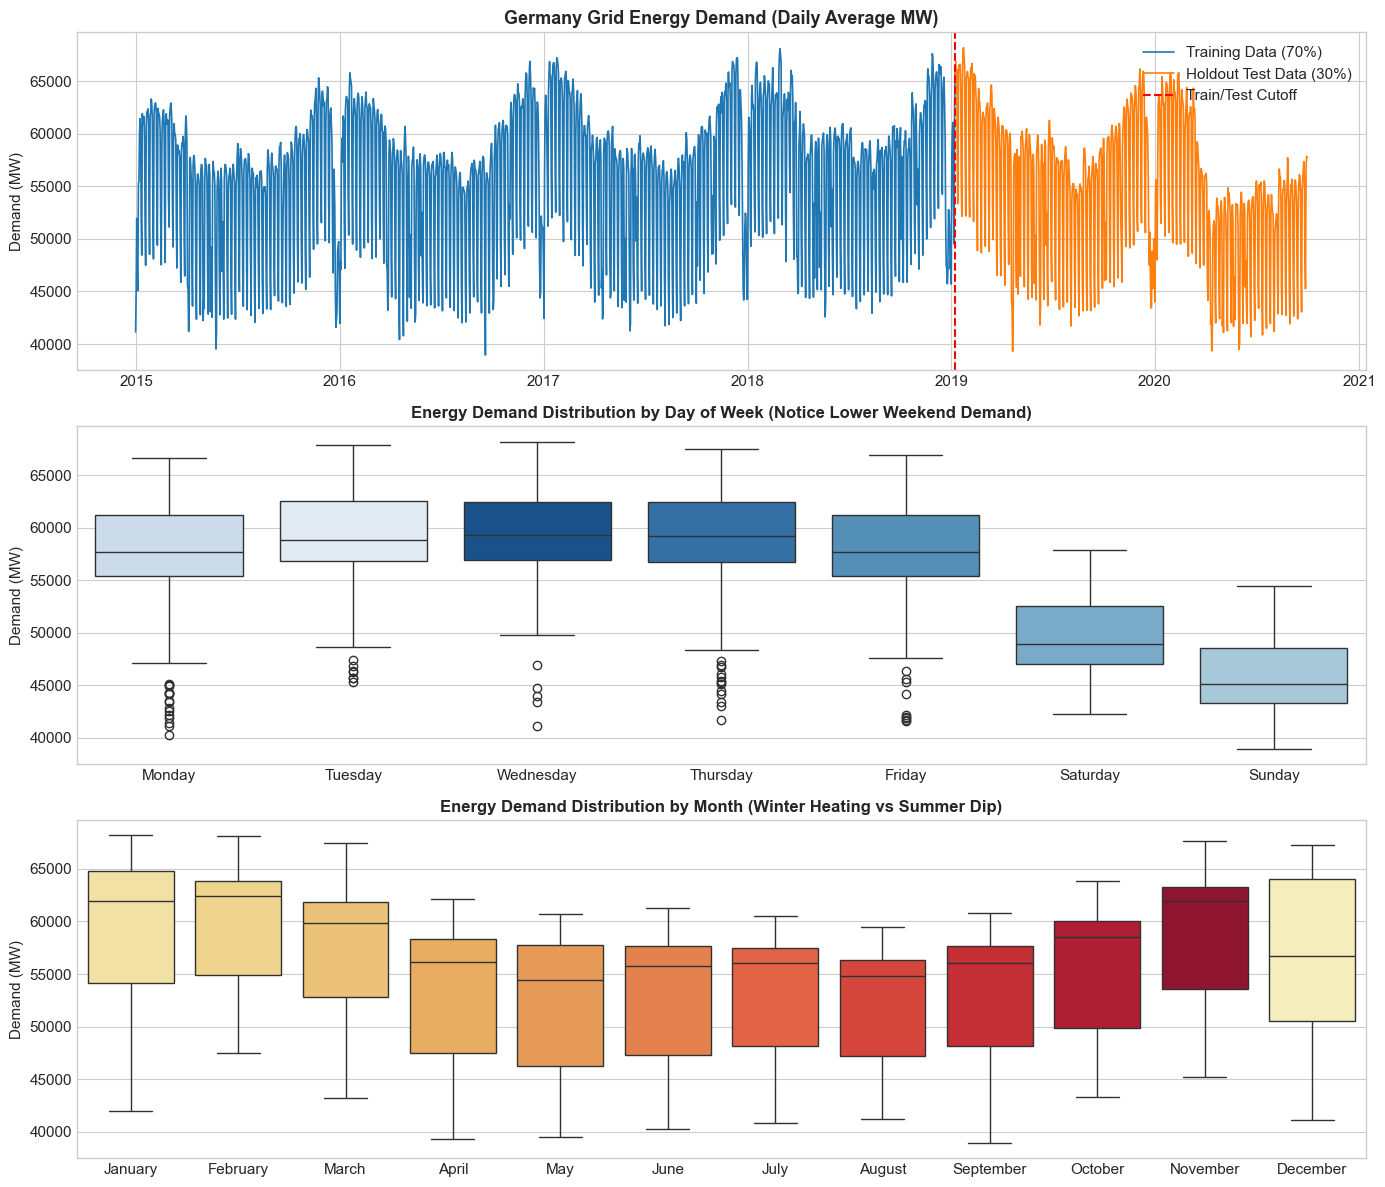

In [7]:
# Exploratory Data Analysis
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Full daily energy demand series with train/test boundary
axes[0].plot(train_daily['ds'], train_daily['y'], label='Training Data (70%)', color='#1f77b4', lw=1.2)
axes[0].plot(test_daily['ds'], test_daily['y'], label='Holdout Test Data (30%)', color='#ff7f0e', lw=1.2)
axes[0].axvline(train_daily['ds'].max(), color='red', linestyle='--', label='Train/Test Cutoff')
axes[0].set_title('Germany Grid Energy Demand (Daily Average MW)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].legend(loc='upper right')

# 2. Weekly seasonal cycle (Day of Week boxplot)
daily_eda = df_daily.copy()
daily_eda['day_of_week'] = daily_eda['ds'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='day_of_week', y='y', data=daily_eda, order=day_order, ax=axes[1], hue='day_of_week', palette='Blues_r', legend=False)
axes[1].set_title('Energy Demand Distribution by Day of Week (Notice Lower Weekend Demand)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('')

# 3. Monthly seasonal cycle (Month of Year boxplot)
daily_eda['month'] = daily_eda['ds'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.boxplot(x='month', y='y', data=daily_eda, order=month_order, ax=axes[2], hue='month', palette='YlOrRd', legend=False)
axes[2].set_title('Energy Demand Distribution by Month (Winter Heating vs Summer Dip)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Demand (MW)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()